In [1]:
import pandas as pd

df = pd.read_csv("retail_sales_dataset.csv")
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


The dataset contains retail transaction data including customer details, product categories, and sales information.

In [2]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


Insight:
The dataset contains 1000 rows and 9 columns
There are no missing values in the dataset
The average sales amount is around 456
Customer age ranges from 18 to 64

In [3]:
df.isnull().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

No missing values are present in the dataset

In [4]:
df.dropna(inplace=True)

Since there were no missing values, no data cleaning was required.

In [5]:
df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


Insight: The average customer age is ~41 years (range: 18–64). The average transaction amount is ₹456, but the median is only ₹135 — this means a few high-value transactions (max ₹2000) are pulling the average up. Quantity always stays between 1–4. Price per unit varies widely (₹25 to ₹500), reflecting different product categories.

In [8]:
df['Date'] = pd.to_datetime(df['Date'])

In [9]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

Date column was converted into datetime format
New features like Year and Month were extracted for time analysis

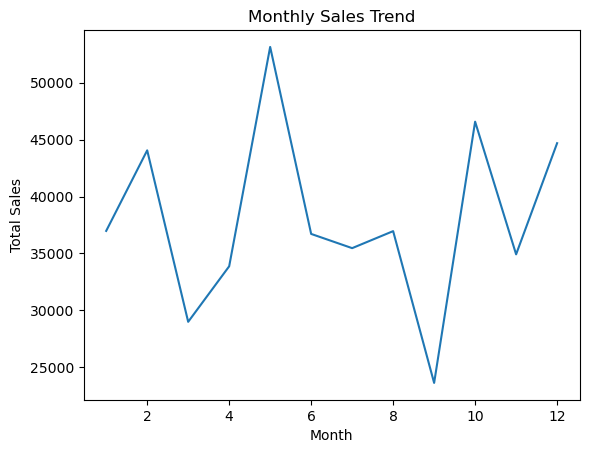

In [10]:
import matplotlib.pyplot as plt

df.groupby('Month')['Total Amount'].sum().plot()
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.show()

Insight: Sales peaked in May (Month 5) at ~₹52,000, showing a clear seasonal high. September (Month 9) recorded the lowest sales at ~₹24,000. A recovery was observed in October and December. The irregular pattern suggests demand is driven by seasonal factors or planned promotions.

Recommendation: Prepare inventory and staffing in advance for peak months like May. Run special discounts or loyalty offers during slow months like September to boost sales.

In [11]:
df.groupby('Product Category')['Total Amount'].sum().sort_values(ascending=False)

Product Category
Electronics    156905
Clothing       155580
Beauty         143515
Name: Total Amount, dtype: int64

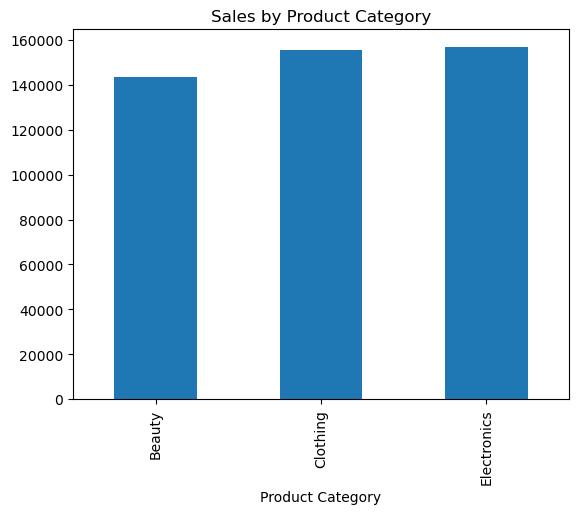

In [12]:
df.groupby('Product Category')['Total Amount'].sum().plot(kind='bar')
plt.title("Sales by Product Category")
plt.show()

Insight: All three categories performed similarly — Electronics (₹1,56,905) > Clothing (₹1,55,580) > Beauty (₹1,43,515). No single category dominates, meaning the business has a well-balanced product portfolio.

Recommendation: Beauty category is slightly behind — targeted promotions or bundle offers can help close the gap. Upselling accessories and warranties in Electronics can further increase revenue.

In [13]:
df.groupby('Gender')['Total Amount'].sum()

Gender
Female    232840
Male      223160
Name: Total Amount, dtype: int64

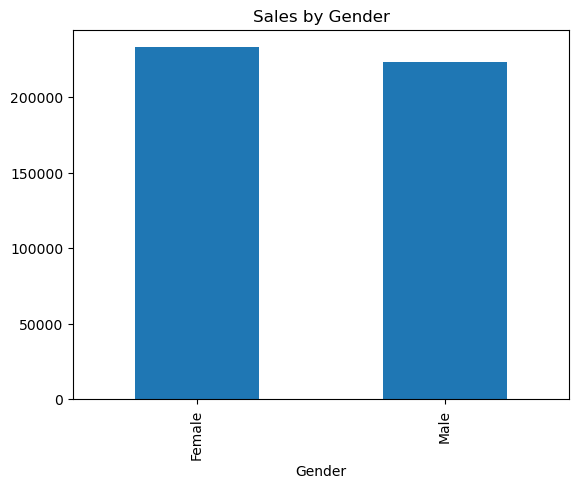

In [14]:
df.groupby('Gender')['Total Amount'].sum().plot(kind='bar')
plt.title("Sales by Gender")
plt.show()

Insight: Female customers contributed ₹2,32,840 while Male customers contributed ₹2,23,160 — a difference of only ~4%. Both genders contribute almost equally to total sales.

Recommendation: Gender-neutral marketing campaigns will be effective. However, a product-level gender breakdown could reveal more specific buying patterns worth targeting.

In [15]:
df.groupby('Age')['Total Amount'].sum()

Age
18    11215
19    14870
20     8645
21    12585
22    13700
23     8220
24     5415
25     9900
26    13980
27     9385
28     8670
29     6570
30     9790
31    10220
32     5550
33     6240
34    16785
35    11290
36     9105
37    11650
38    11100
39     4595
40     9415
41     5650
42     8500
43    17970
44     7560
45     6325
46    13090
47    12505
48     7240
49     5110
50     9845
51    16065
52     7040
53     9510
54    10505
55     9780
56     9440
57     9290
58     7395
59     9470
60    11590
61     6730
62     8120
63     9250
64     9125
Name: Total Amount, dtype: int64

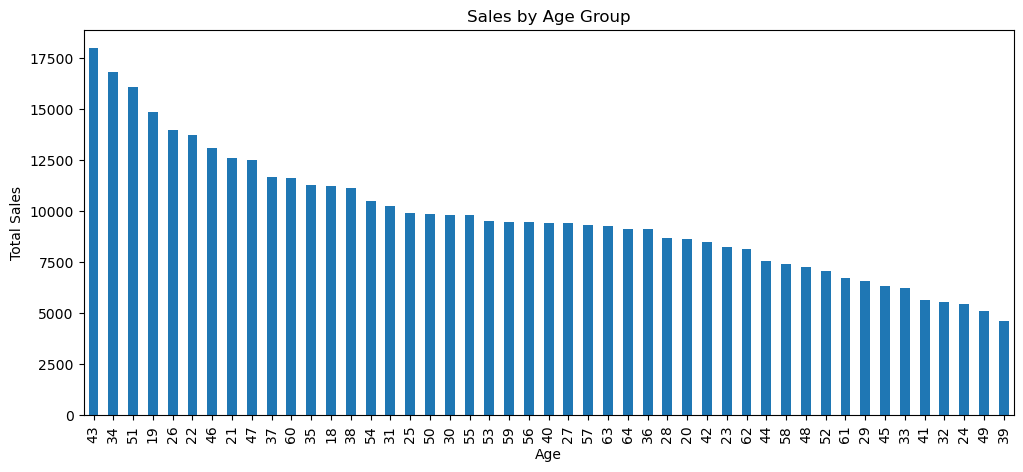

In [17]:
age_sales = df.groupby('Age')['Total Amount'].sum()

age_sales.sort_values(ascending=False).plot(kind='bar', figsize=(12,5))
plt.title("Sales by Age Group")
plt.xlabel("Age")
plt.ylabel("Total Sales")
plt.show()

Insight: Sales are not evenly distributed across age groups. Notable peaks are at Age 43 (₹17,970), Age 34 (₹16,785), and Age 51 (₹16,065). Younger customers aged 18–25 tend to spend comparatively less.

Recommendation: The 30–55 age group is the most valuable customer segment — focus marketing and premium products on this group. To attract younger customers (18–25), consider introducing budget-friendly ranges or EMI/installment options.

In [18]:
df.groupby('Customer ID')['Total Amount'].sum().sort_values(ascending=False).head()

Customer ID
CUST487    2000
CUST476    2000
CUST773    2000
CUST503    2000
CUST093    2000
Name: Total Amount, dtype: int64

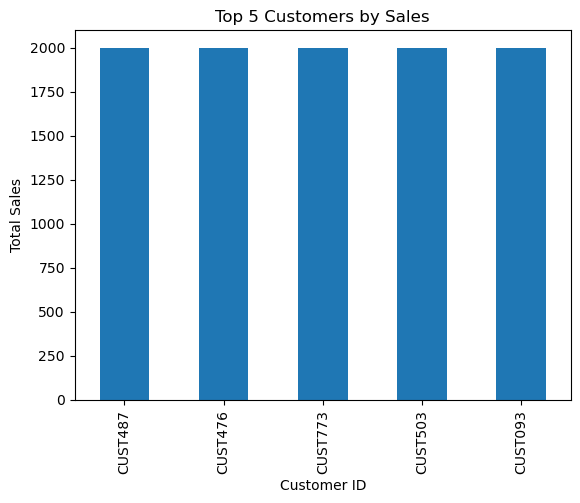

In [20]:
top_customers = df.groupby('Customer ID')['Total Amount'].sum().sort_values(ascending=False).head()

top_customers.plot(kind='bar')
plt.title("Top 5 Customers by Sales")
plt.xlabel("Customer ID")
plt.ylabel("Total Sales")
plt.show()

Insight: The top 5 customers (CUST487, CUST476, CUST773, CUST503, CUST093) each spent exactly ₹2,000 — the maximum transaction value in the dataset. These are likely single high-value purchases, possibly in Electronics.

Recommendation: Introduce a VIP loyalty program with exclusive discounts for high-spending customers. Retaining existing high-value customers is more cost-effective than acquiring new ones.

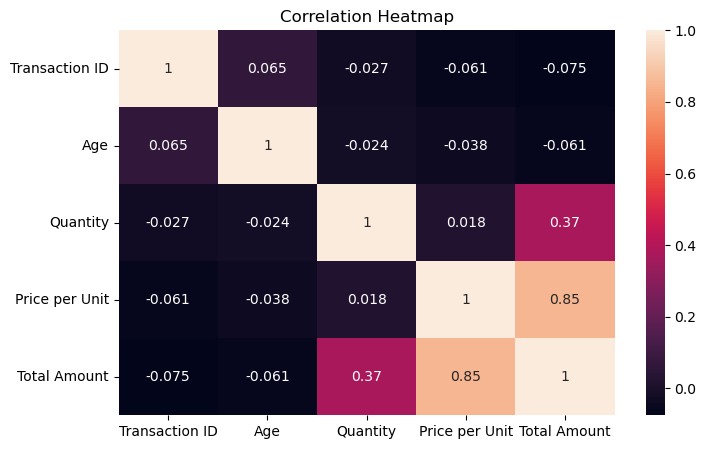

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(8,5))
sns.heatmap(numeric_df.corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

Insight: The strongest correlation is between Price per Unit and Total Amount (0.85) — meaning higher-priced products directly drive higher revenue. Quantity and Total Amount also show a moderate correlation (0.37). Age has no meaningful correlation with any variable, meaning age alone cannot predict purchasing behavior.

Recommendation: Promoting premium/high-price products is the most effective strategy to increase revenue. Bundle deals that increase quantity per transaction can also meaningfully boost total sales

Final Overall Recommendations :
1. Seasonal Strategy: May is the peak month — plan stock and campaigns in advance. Run flash sales in September to counter the seasonal dip.
2. Product Focus: All three categories are balanced, but Beauty needs a slight push through targeted offers or combo deals.
3. Customer Segmentation: Target the 30–55 age group with premium products. Introduce budget-friendly options for younger customers aged 18–25.
4. VIP Program: Launch a loyalty rewards program for top spenders to improve retention.
5. Pricing Strategy: High-price items are the strongest driver of revenue — consider expanding the premium product line.